In [1]:
import pandas as pd
import numpy as np
import urllib

from sqlalchemy import create_engine

import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [2]:
server = r"DEVIL\SQLEXPRESS"
database = "ecommerce"

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" + params,
    pool_pre_ping=True
)

print("Connected!")

Connected!


In [3]:
rfm = pd.read_sql(
    """
    SELECT 
        customer_unique_id,
        recency,
        frequency,
        monetary
    FROM dbo.Customer_RFM
    """,
    engine
)

c:\Users\sahuj\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [4]:
rfm.describe()

,recency,frequency,monetary
count,93357.000000,93357.000000,93357.000000
mean,237.473783,1.033420,165.198772
std,152.587935,0.209099,226.314579
min,0.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060001
50%,218.000000,1.000000,107.780003
75%,346.000000,1.000000,182.559998
max,695.000000,15.000000,13664.080078


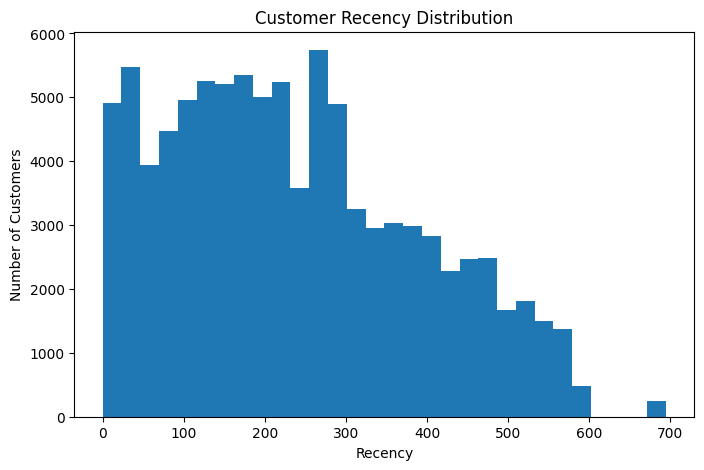

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["recency"],
    bins=30
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Number of Customers")

plt.show()

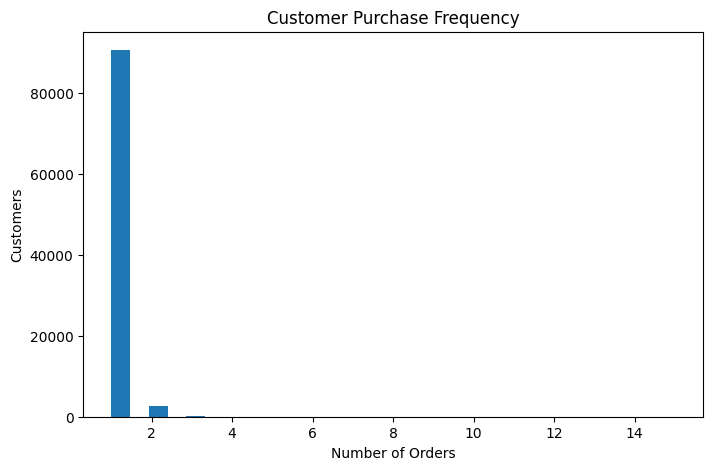

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["frequency"],
    bins=30
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.show()

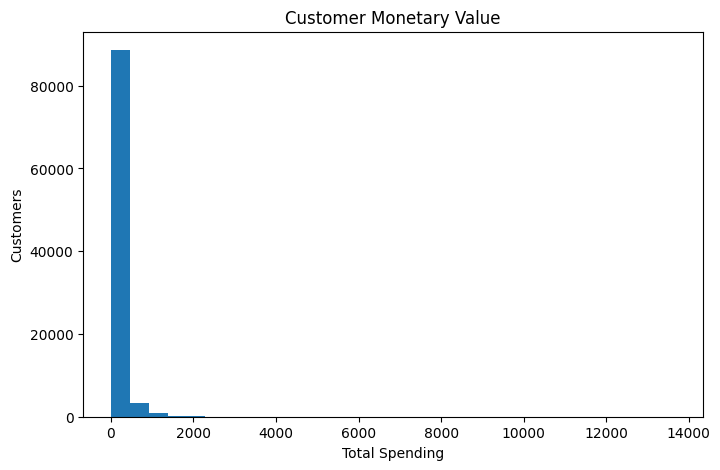

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["monetary"],
    bins=30
)

plt.title("Customer Monetary Value")
plt.xlabel("Total Spending")
plt.ylabel("Customers")

plt.show()

In [8]:
top_customers = (
    rfm
    .sort_values("monetary", ascending=False)
    .head(10)
)

top_customers

,customer_unique_id,recency,frequency,monetary
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.080078
79635,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.629883
43168,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.879883
80462,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.310059
25436,459bef486812aa25204be022145caa62,35,1,6922.209961
93080,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.660156
23411,4007669dec559734d6f53e029e360987,278,1,6081.540039
87147,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.339844
26640,48e1ac109decbb87765a3eade6854098,68,1,4681.779785
73126,c8460e4251689ba205045f3ea17884a1,21,4,4655.910034
